# SVM
- breast_Cancer.csv
- Hyperparameter tuning


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions
from sklearn.decomposition import PCA

In [51]:
df = pd.read_csv('breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [52]:
df = df.drop(columns={'id','Unnamed: 32'})

In [53]:
encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

In [54]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [55]:
# Features and target
x = df.iloc[:, 1:-1]
y = df.iloc[:, 0]

scaler = StandardScaler()

# split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [56]:
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['sigmoid'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'class_weight': [None, 'balanced']
    }
]

grid = GridSearchCV(estimator = SVC(probability=True),
                    param_grid = param_grid,
                    cv = 5,
                    scoring = 'accuracy',
                    n_jobs = -1)

grid.fit(x_train, y_train)

print('✅ Best score: ',grid.best_score_)
print('🚀 Best model: ',grid.best_estimator_)
print('🔰 Best hyperparameters : ',grid.best_params_)

✅ Best score:  0.9868131868131869
🚀 Best model:  SVC(C=1, class_weight='balanced', gamma=0.01, probability=True)
🔰 Best hyperparameters :  {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}


In [57]:
# best model.
best_model = grid.best_estimator_

accuracy :  0.956140350877193



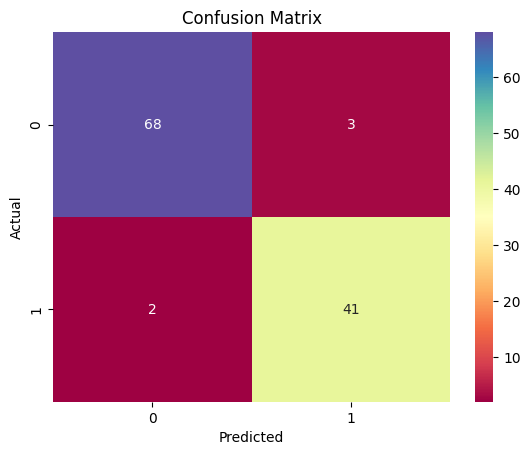

In [58]:
# evaluation
y_Pred = best_model.predict(x_test)
print('accuracy : ',accuracy_score(y_test, y_Pred))

print()

sns.heatmap(confusion_matrix(y_test, y_Pred), annot = True, cmap = 'Spectral')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

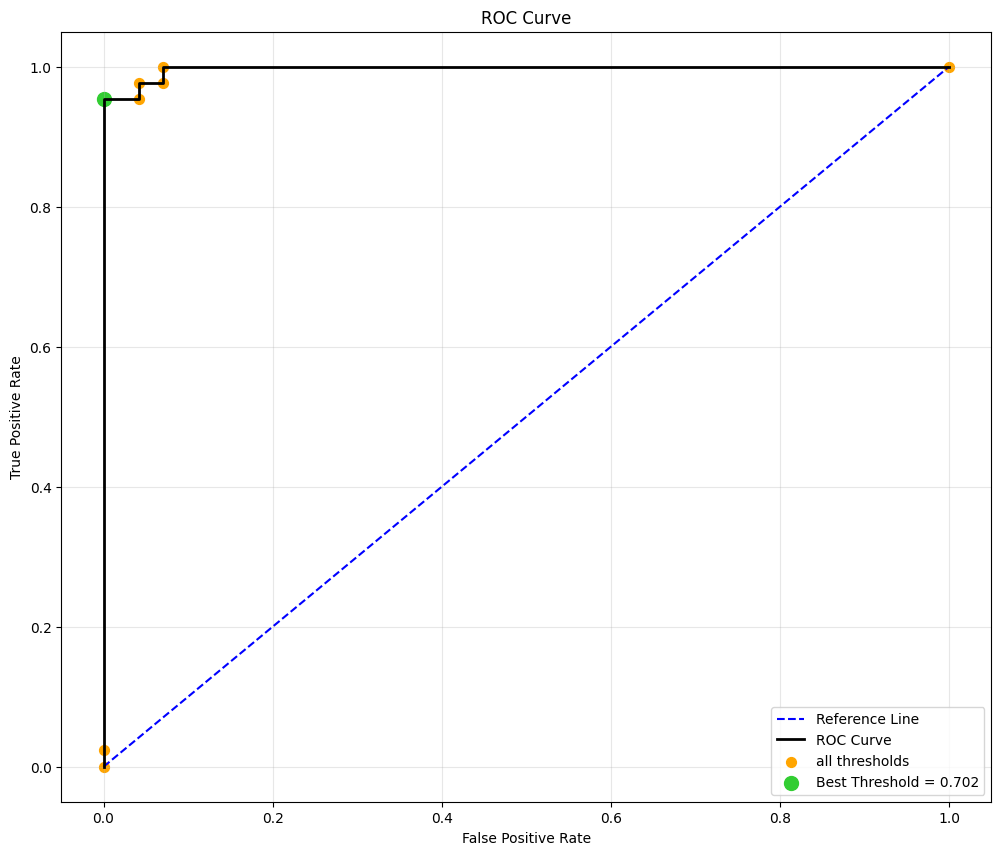


 AUC Score: 0.99737962659679


In [59]:
# ROC curve
y_Score = best_model.predict_proba(x_test)[:, 1]

# optimal threshold
fpr, tpr, thresholds = roc_curve(y_test, y_Score)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]


plt.figure(figsize=(12,10))

plt.plot([0,1], [0,1], '--', color='blue', label='Reference Line')
plt.plot(fpr, tpr, color='black', linewidth=2, label='ROC Curve')
plt.scatter(fpr, tpr, color = 'orange', s = 50, label = 'all thresholds')
plt.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color='limegreen',
    s=100,
    label=f'Best Threshold = {optimal_threshold:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("\n AUC Score:", roc_auc_score(y_test, y_Score))

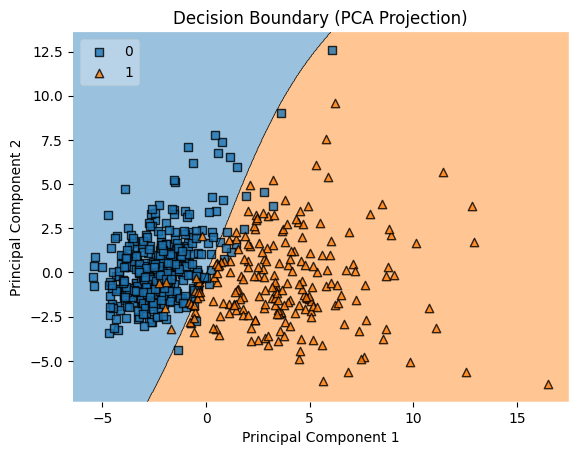

In [60]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(scaler.transform(x))

best_model.fit(x_pca, y)

plot_decision_regions(x_pca,y.to_numpy(),clf=best_model,legend=2)
plt.title("Decision Boundary (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [66]:
type(y_Pred)
y_Pred = pd.Series(y_Pred)
y_Pred

,0
0,0
1,1
2,1
3,0
4,0
...,...
109,0
110,1
111,0
112,0


In [68]:
actual = df['diagnosis']

In [73]:
actual_vs_pred = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicted' : y_Pred.values
})

actual_vs_pred

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
...,...,...
109,0,0
110,1,1
111,0,0
112,0,0
